# Convert SDFs into `SDFdataset` as a member of the `GNNdataset` that inherits PyTorch Geometric `Dataset` for data handling methods 

## Load sdf and test feature extraction

In [1]:
# import sys
# sys.path.append("..")  # Ensure notebook can find the package

from rdkit import Chem
from atoMLtype.GNN.GNNfeaturizer import GraphFeaturizer
import importlib

# Load the SDF file
sdf_path = "./data/parm_at_Frosst/zinc.sdf"
json_labels = "./data/antechamber/atomLabels_gaff2.json"
suppl = Chem.SDMolSupplier(sdf_path, removeHs=False)

# Initialize Featurizer
featurizer = GraphFeaturizer()

# Extract Features from First Molecule
mol = suppl[0]  # Get first molecule
if mol is not None:
    print(f"mol: {mol.GetProp('_Name')}")
    atom_features, edge_indices, bond_features = featurizer.featurize(mol)

    print("Atom Features (Node Features):")
    for i, f in enumerate(atom_features):
        print(f"Atom {i}: {f}")

    print("\nBond Features (Edge Features):")
    for i, (idx, f) in enumerate(zip(edge_indices, bond_features)):
        print(f"Bond {idx}: {f}")



mol: ZINC05768049
Atom Features (Node Features):
Atom 0: [0.      0.      0.      0.      0.      1.      0.      0.      0.
 0.      0.      0.      0.      0.      0.      0.      0.      0.
 0.      0.      0.      0.      0.      0.      0.      0.      0.
 0.      0.      0.      0.      0.      0.      0.      0.      0.
 0.      0.      0.      0.      0.      0.      0.      0.      0.
 0.      0.      0.      0.      0.      0.      0.      0.      0.
 0.      0.      0.      0.      0.      0.      0.      0.      0.
 0.      0.      0.      0.      0.      0.      0.      0.      0.
 0.      0.      0.      0.      0.      0.      0.      0.      0.
 0.      0.      0.      0.      0.      0.      0.      0.      0.
 0.      0.      0.      0.      0.      0.      0.      0.      0.
 0.      0.      0.      0.      0.      1.      0.      0.      0.
 0.      0.      0.      0.      0.      0.      0.      0.      1.
 0.      0.      0.      0.      0.      0.12011 0.      1.

## Test GNNdataset


In [2]:
# import atoMLtype
from atoMLtype.GNN.GNNdataset import GNNdataset
from torch_geometric.loader import DataLoader

# importlib.reload(atoMLtype)
# from atoMLtype.RF.GNNdataset import GNNdataset

# Initialize Dataset
dataset = GNNdataset(sdf_path,json_labels)

# Check First Graph
graph = dataset[0]
print("Graph Representation:")
print(graph)

print("\nNode Features Shape:", graph.x.shape)  # (num_nodes, num_features)
print("Edge Index Shape:", graph.edge_index.shape)  # (2, num_edges)
print("Edge Features Shape:", graph.edge_attr.shape)  # (num_edges, edge_feature_dim)


[20:54:30] Explicit valence for atom # 9 N, 5, is greater than permitted
Sanitization failed for molecule at index 2131, Name: ZINC16448882. Skipping sanitization: Explicit valence for atom # 9 N, 5, is greater than permitted
[20:54:30] Explicit valence for atom # 7 N, 5, is greater than permitted
Sanitization failed for molecule at index 2721, Name: ZINC15772239. Skipping sanitization: Explicit valence for atom # 7 N, 5, is greater than permitted
[20:54:30] Explicit valence for atom # 10 N, 5, is greater than permitted
Sanitization failed for molecule at index 3249, Name: ZINC11539132. Skipping sanitization: Explicit valence for atom # 10 N, 5, is greater than permitted
[20:54:30] Explicit valence for atom # 3 N, 5, is greater than permitted
Sanitization failed for molecule at index 5699, Name: ZINC17111082. Skipping sanitization: Explicit valence for atom # 3 N, 5, is greater than permitted
Skipping molecule ZINC59391023: Missing from JSON.
Skipping molecule ZINC00335972: Missing fro

Graph Representation:
Data(x=[29, 136], edge_index=[2, 28], edge_attr=[28, 14], y=[29])

Node Features Shape: torch.Size([29, 136])
Edge Index Shape: torch.Size([2, 28])
Edge Features Shape: torch.Size([28, 14])


## Test data handling of PyG dataset that is inherited in GNNdataset

In [3]:
# Use PyTorch Geometric DataLoader
dataloader = DataLoader(dataset, batch_size=5, shuffle=True)

# Check one batch
for batch in dataloader:
    print("\nBatched Graph:")
    print(batch)
    print("\nBatched Node Feature Shape:", batch.x.shape)
    print("Batched Edge Index Shape:", batch.edge_index.shape)
    print("Batched Edge Feature Shape:", batch.edge_attr.shape)
    break  # Only print one batch



Batched Graph:
DataBatch(x=[107, 136], edge_index=[2, 113], edge_attr=[113, 14], y=[107], batch=[107], ptr=[6])

Batched Node Feature Shape: torch.Size([107, 136])
Batched Edge Index Shape: torch.Size([2, 113])
Batched Edge Feature Shape: torch.Size([113, 14])


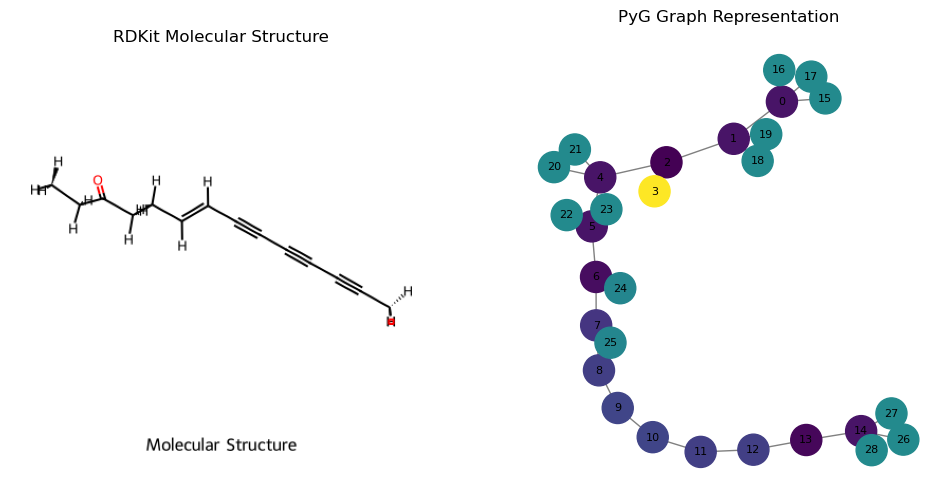

In [4]:
import matplotlib.pyplot as plt
import networkx as nx
import torch
from rdkit import Chem
from rdkit.Chem import Draw
from torch_geometric.utils import to_networkx

def visualize_molecular_graph(data, mol=None, atom_labels=None):
    """
    Visualizes the RDKit molecular structure next to its PyG graph representation.

    Args:
        data (torch_geometric.data.Data): PyG molecular graph.
        mol (rdkit.Chem.Mol, optional): RDKit molecule object for reference.
        atom_labels (dict, optional): Dictionary mapping atom indices to labels.
    """
    fig, axes = plt.subplots(1, 2, figsize=(12, 6))

    # ---- Left Side: RDKit Molecular Structure ----
    if mol:
        atom_indices = [str(atom.GetIdx()) for atom in mol.GetAtoms()]  # Get atom indices
        img = Draw.MolToImage(mol, size=(400, 400), legend="Molecular Structure")
        axes[0].imshow(img)
        axes[0].axis('off')
        axes[0].set_title("RDKit Molecular Structure")

    # ---- Right Side: PyG Graph Representation ----
    G = to_networkx(data, to_undirected=True)

    # Assign colors based on atom types
    node_colors = [data.y[i].item() if data.y is not None else 0 for i in range(data.num_nodes)]

    # Layout for better visualization
    pos = nx.spring_layout(G, seed=42)
    
    nx.draw(G, pos, with_labels=True, node_color=node_colors, cmap=plt.cm.viridis, 
            node_size=500, font_size=8, edge_color='gray', ax=axes[1])
    
    axes[1].set_title("PyG Graph Representation")
    
    plt.show()



# Get a sample graph
# Select a molecule
data = dataset[0]  # First molecule in dataset
mol_name = list(dataset.sdf_dataset.X_molecules.keys())[0]  # Get the molecule name
mol = dataset.sdf_dataset.X_molecules[mol_name]  # Retrieve RDKit Mol object

# Visualize
visualize_molecular_graph(data, mol)

